### PACOTES

In [149]:
import matplotlib.pyplot as plt
import pandas as pd
import time
import seaborn as sns
from openTSNE import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, classification_report, auc, precision_recall_curve


#### INICIO DA MARCACAO DO TEMPO

In [150]:
inicio = time.perf_counter()

### Importar e separar o csv

In [151]:

#Dataset com scores das combinações
df_scores = pd.read_csv('2x2visu_scores.csv')

#Dataset original
df = pd.read_csv('creditcard.csv')

#PEGAR TOP 5
top_5 = df_scores.nlargest(5, 'Score_Final')

#Lista das features
features_list = top_5['Features'].tolist()

#MOSTRAR TOP 5
for i, feature in enumerate(features_list, start=1):

    x, y = feature.split('|')

    x = x.strip()
    y = y.strip()

    print(f'\n{i}º Feature Completa: {feature}')
    print(f'Variável x{i}: {x}')
    print(f'Variável y{i}: {y}')


1º Feature Completa: V10 | V14
Variável x1: V10
Variável y1: V14

2º Feature Completa: V12 | V14
Variável x2: V12
Variável y2: V14

3º Feature Completa: V10 | V11
Variável x3: V10
Variável y3: V11

4º Feature Completa: V14 | V17
Variável x4: V14
Variável y4: V17

5º Feature Completa: V11 | V17
Variável x5: V11
Variável y5: V17


# 1st

### ORIGINAL



RANK ESCOLHIDO: 1
FEATURE: V10 | V14


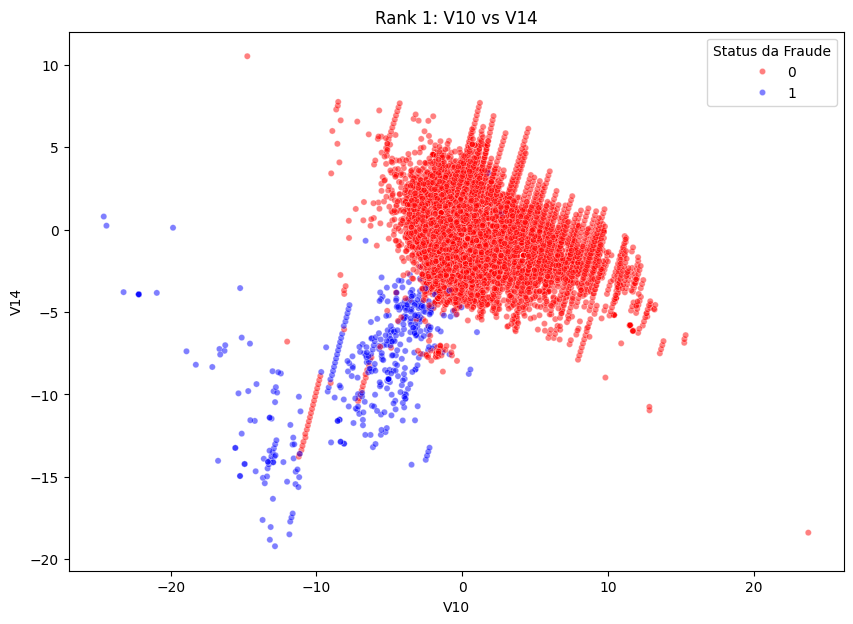

In [152]:
posicao_rank = 1
# 1 = melhor dupla
# 2 = segunda melhor
# ...

# PEGAR FEATURE ESCOLHIDA
feature_escolhida = features_list[posicao_rank - 1]

x, y = feature_escolhida.split('|')

x = x.strip()
y = y.strip()

print('\n=========================')
print(f'RANK ESCOLHIDO: {posicao_rank}')
print(f'FEATURE: {feature_escolhida}')
print('=========================')


# GRÁFICO 2D
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x=x,
    y=y,
    hue='status_fraude',
    palette={
        0: 'red',
        1: 'blue'
    },
    alpha=0.5,
    s=20
)

plt.title(f'Rank {posicao_rank}: {x} vs {y}')

plt.xlabel(x)
plt.ylabel(y)

plt.legend(title='Status da Fraude')

plt.show()


#### GMM NA ORIGINAL 

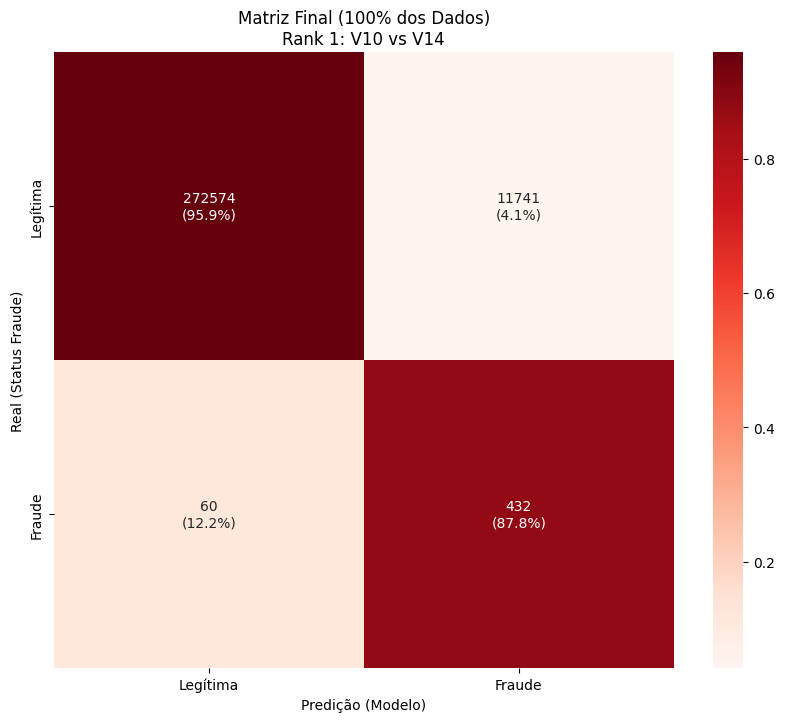

Tempo de execução: 4.2676s
Total de registros analisados: 284807

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    284315
           1       0.04      0.88      0.07       492

    accuracy                           0.96    284807
   macro avg       0.52      0.92      0.52    284807
weighted avg       1.00      0.96      0.98    284807

AUC-PR: 0.4396


In [153]:


#DEFINIÇÃO DAS VARIÁVEIS DO RANKING
feature_escolhida = features_list[posicao_rank - 1]
x_col, y_col = [f.strip() for f in feature_escolhida.split('|')]

X_bruto = df[[x_col, y_col]]
y_real = df['status_fraude']

#ESCALONAMENTO E TREINO (GMM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bruto)

inicio = time.perf_counter()
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
fim = time.perf_counter()

#IDENTIFICAÇÃO DO CLUSTER DE FRAUDE
clusters = gmm.predict(X_scaled)
ct = pd.crosstab(clusters, y_real)
cluster_fraude = ct[1].idxmax() # Qual cluster tem mais fraudes (1)

#PREDIÇÃO E PROBABILIDADE
probabilidades = gmm.predict_proba(X_scaled)[:, cluster_fraude]
y_pred = (probabilidades > 0.50).astype(int)

#MATRIZ DE CONFUSÃO (BRUTO + PORCENTAGEM)
cm = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

#Formatação dos Labels para mostrar valor real e %
labels = [f"{int(val)}\n({pct:.1%})" for val, pct in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(2, 2)

#VISUALIZAÇÃO
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=labels, fmt="", cmap='Reds',
            xticklabels=['Legítima', 'Fraude'], 
            yticklabels=['Legítima', 'Fraude'])

plt.title(f'Matriz Final (100% dos Dados)\nRank {posicao_rank}: {x_col} vs {y_col}')
plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')
plt.show()

#MÉTRICAS DE MERCADO NO TERMINAL
print(f"Tempo de execução: {fim - inicio:.4f}s")
print(f"Total de registros analisados: {len(df)}")
print("\nRelatório de Classificação:")
print(classification_report(y_real, y_pred))

precision_vals, recall_vals, _ = precision_recall_curve(y_real, probabilidades)
print(f"AUC-PR: {auc(recall_vals, precision_vals):.4f}")

### T-SNE

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=7, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 104.40 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 31.20 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.22 seconds
===> Running optimization with exaggeration=12.00, lr=23733.92 for 250 iterations...
Iteration   50, KL divergence 6.2762, 50 iterations in 23.9754 sec
Iteration  100, KL divergence 5.8082, 50 iterations in 22.9412 sec
Iteration  150, KL divergence 5.3803, 50 iterations in 23.5076 sec
Iteration  200, KL divergence 5.1142, 50 iterations in 25.0082 sec
Iteration  250, KL divergence 4.9235, 50 iterations in 24.6329 sec
   --> Time elapsed: 120.07 seconds
===> Running optimization with exa

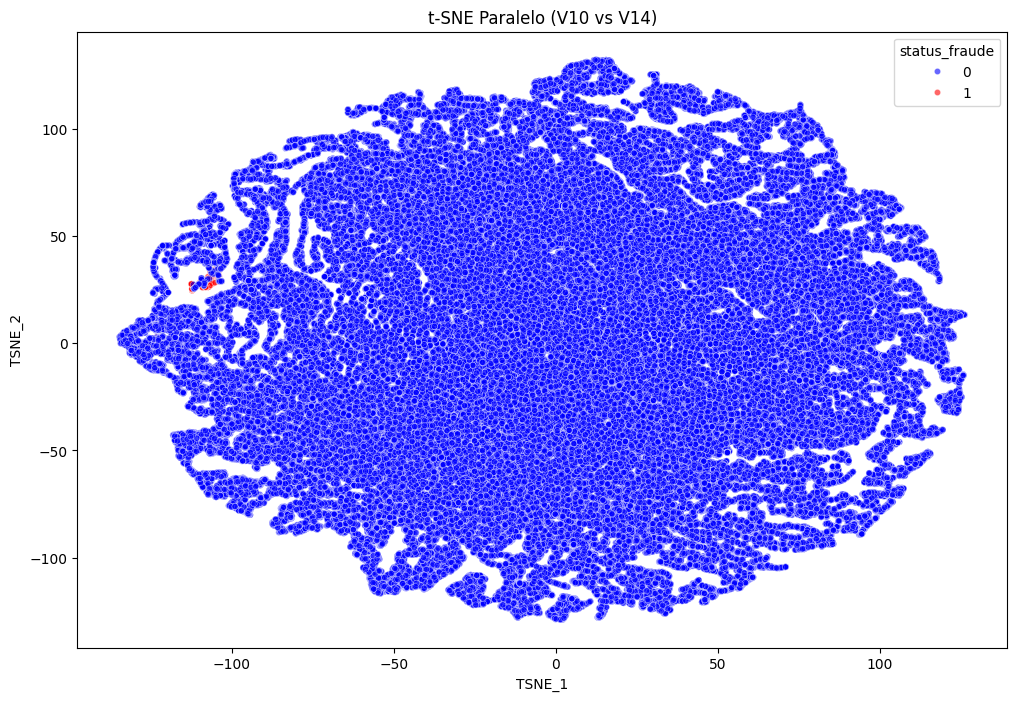

In [154]:
feature_escolhida = features_list[posicao_rank - 1]

x, y = feature_escolhida.split('|')

x = x.strip()
y = y.strip()

# FRAUDES E NÃO FRAUDES
df_fraude = df[df['status_fraude'] == 1]

df_nao_fraude = df[df['status_fraude'] == 0]


df_nao_fraude_sample = df_nao_fraude.sample(
    frac=1.0,
    random_state=42
)

#Juntando
df_tsne = pd.concat(
    [df_fraude, df_nao_fraude_sample],
    axis=0
)
 
#FEATURES

X = df_tsne[[x, y]]

#Padronização
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# t-SNE PARALELO
tsne = TSNE(
    n_components=2,
    perplexity=30,
    initialization='pca',
    n_jobs=7,
    random_state=42,
    verbose=True
)

X_tsne = tsne.fit(X_scaled)

# DATAFRAME FINAL
df_plot = pd.DataFrame()

df_plot['TSNE_1'] = X_tsne[:, 0]
df_plot['TSNE_2'] = X_tsne[:, 1]

df_plot['status_fraude'] = df_tsne['status_fraude'].values

#PLOT 
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_plot,
    x='TSNE_1',
    y='TSNE_2',
    hue='status_fraude',
    palette={
        0: 'blue',
        1: 'red'
    },
    alpha=0.6,
    s=20
)

plt.title(
    f't-SNE Paralelo ({x} vs {y})'
)

plt.show()

#### GMM NA T-SNE

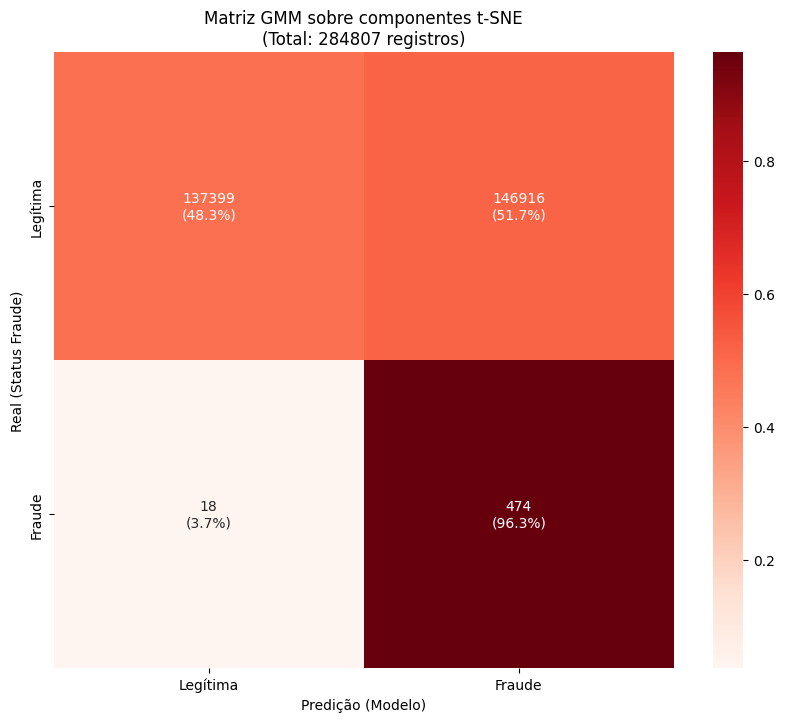


AUC-PR FINAL: 0.0173
              precision    recall  f1-score   support

    Legítima       1.00      0.48      0.65    284315
      Fraude       0.00      0.96      0.01       492

    accuracy                           0.48    284807
   macro avg       0.50      0.72      0.33    284807
weighted avg       1.00      0.48      0.65    284807



In [155]:
#PREPARAÇÃO DOS DADOS DO t-SNE 
# Usando o DataFrame que você já criou (df_plot)
X_tsne_cols = df_plot[['TSNE_1', 'TSNE_2']]
y_real = df_plot['status_fraude']

#MODELAGEM GMM
# Treinando nos dados transformados pelo t-SNE
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_tsne_cols)

#Identificando o cluster de fraude automaticamente
clusters = gmm.predict(X_tsne_cols)
ct = pd.crosstab(clusters, y_real)
cluster_fraude = ct[1].idxmax()

#Pegando as probabilidades
probabilidades = gmm.predict_proba(X_tsne_cols)[:, cluster_fraude]
y_pred = (probabilidades > 0.50).astype(int)

#MÉTRICAS E MATRIZ 
cm = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

#Criando labels com Bruto + Porcentagem
labels = [f"{int(val)}\n({pct:.1%})" for val, pct in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(2, 2)

#VISUALIZAÇÃO 
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm, 
    annot=labels, 
    fmt="", 
    cmap='Reds', 
    xticklabels=['Legítima', 'Fraude'], 
    yticklabels=['Legítima', 'Fraude']
)

plt.title(f'Matriz GMM sobre componentes t-SNE\n(Total: {len(df_plot)} registros)')
plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')
plt.show()

# Relatório de Mercado
precision_vals, recall_vals, _ = precision_recall_curve(y_real, probabilidades)
print("\n" + "="*40)
print(f"AUC-PR FINAL: {auc(recall_vals, precision_vals):.4f}")
print("="*40)
print(classification_report(y_real, y_pred, target_names=['Legítima', 'Fraude']))

# 2st 

### ORIGINAL



RANK ESCOLHIDO: 2
FEATURE: V12 | V14


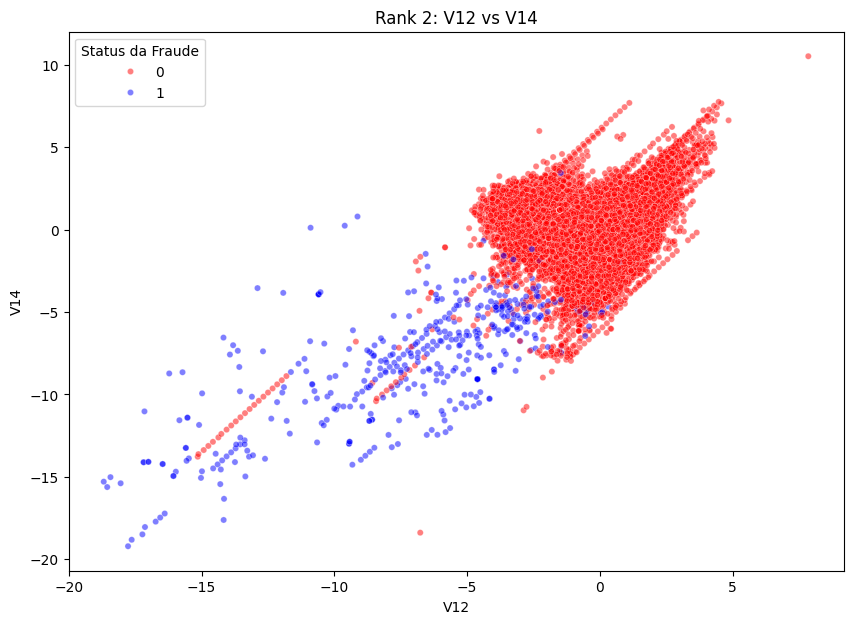

In [156]:
posicao_rank = 2
# 1 = melhor dupla
# 2 = segunda melhor
# ...

# PEGAR FEATURE ESCOLHIDA
feature_escolhida = features_list[posicao_rank - 1]

x, y = feature_escolhida.split('|')

x = x.strip()
y = y.strip()

print('\n=========================')
print(f'RANK ESCOLHIDO: {posicao_rank}')
print(f'FEATURE: {feature_escolhida}')
print('=========================')


# GRÁFICO 2D
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x=x,
    y=y,
    hue='status_fraude',
    palette={
        0: 'red',
        1: 'blue'
    },
    alpha=0.5,
    s=20
)

plt.title(f'Rank {posicao_rank}: {x} vs {y}')

plt.xlabel(x)
plt.ylabel(y)

plt.legend(title='Status da Fraude')

plt.show()


#### GMM NA ORIGINAL 

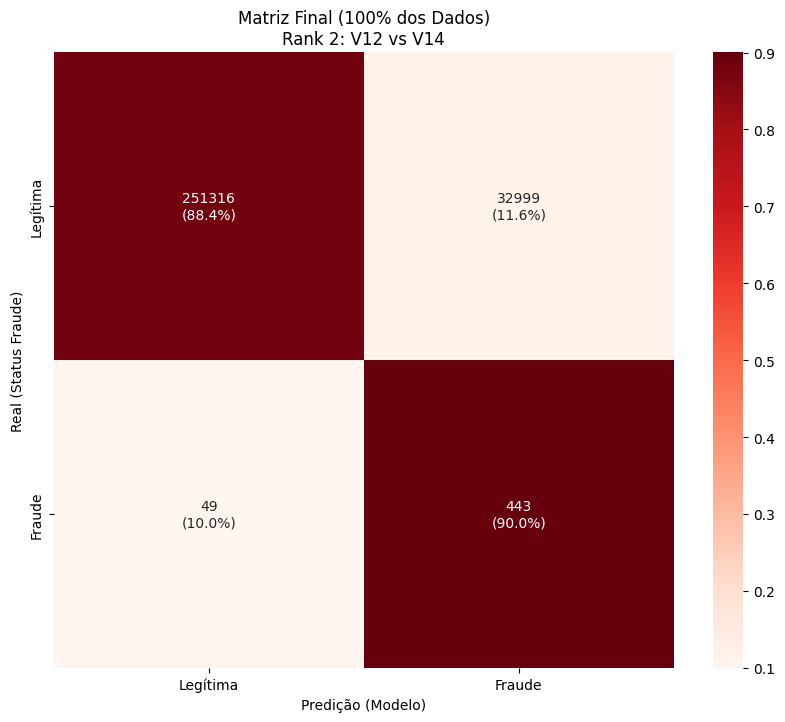

Tempo de execução: 1.9998s
Total de registros analisados: 284807

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    284315
           1       0.01      0.90      0.03       492

    accuracy                           0.88    284807
   macro avg       0.51      0.89      0.48    284807
weighted avg       1.00      0.88      0.94    284807

AUC-PR: 0.6473


In [157]:


#DEFINIÇÃO DAS VARIÁVEIS DO RANKING
feature_escolhida = features_list[posicao_rank - 1]
x_col, y_col = [f.strip() for f in feature_escolhida.split('|')]

X_bruto = df[[x_col, y_col]]
y_real = df['status_fraude']

#ESCALONAMENTO E TREINO (GMM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bruto)

inicio = time.perf_counter()
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
fim = time.perf_counter()

#IDENTIFICAÇÃO DO CLUSTER DE FRAUDE
clusters = gmm.predict(X_scaled)
ct = pd.crosstab(clusters, y_real)
cluster_fraude = ct[1].idxmax() # Qual cluster tem mais fraudes (1)

#PREDIÇÃO E PROBABILIDADE
probabilidades = gmm.predict_proba(X_scaled)[:, cluster_fraude]
y_pred = (probabilidades > 0.50).astype(int)

#MATRIZ DE CONFUSÃO (BRUTO + PORCENTAGEM)
cm = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

#Formatação dos Labels para mostrar valor real e %
labels = [f"{int(val)}\n({pct:.1%})" for val, pct in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(2, 2)

#VISUALIZAÇÃO
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=labels, fmt="", cmap='Reds',
            xticklabels=['Legítima', 'Fraude'], 
            yticklabels=['Legítima', 'Fraude'])

plt.title(f'Matriz Final (100% dos Dados)\nRank {posicao_rank}: {x_col} vs {y_col}')
plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')
plt.show()

#MÉTRICAS DE MERCADO NO TERMINAL
print(f"Tempo de execução: {fim - inicio:.4f}s")
print(f"Total de registros analisados: {len(df)}")
print("\nRelatório de Classificação:")
print(classification_report(y_real, y_pred))

precision_vals, recall_vals, _ = precision_recall_curve(y_real, probabilidades)
print(f"AUC-PR: {auc(recall_vals, precision_vals):.4f}")

### T-SNE

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=7, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 99.42 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 30.08 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.15 seconds
===> Running optimization with exaggeration=12.00, lr=23733.92 for 250 iterations...
Iteration   50, KL divergence 6.2680, 50 iterations in 25.6002 sec
Iteration  100, KL divergence 5.8012, 50 iterations in 25.0611 sec
Iteration  150, KL divergence 5.3706, 50 iterations in 24.3674 sec
Iteration  200, KL divergence 5.1021, 50 iterations in 24.6434 sec
Iteration  250, KL divergence 4.9096, 50 iterations in 24.5337 sec
   --> Time elapsed: 124.21 seconds
===> Running optimization with exag

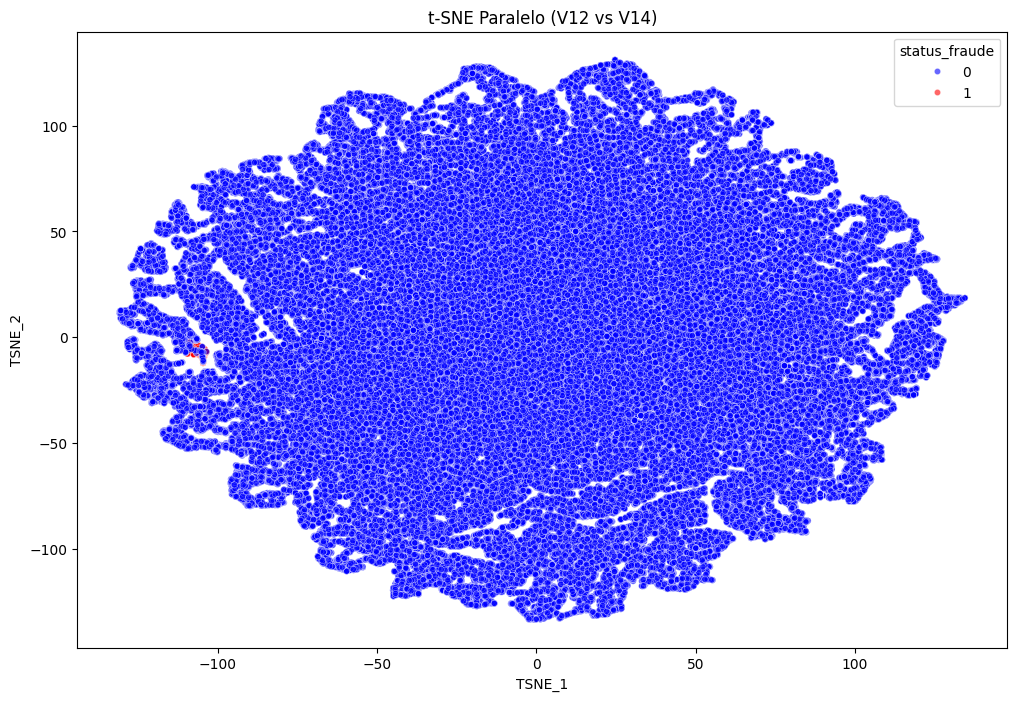

In [158]:
feature_escolhida = features_list[posicao_rank - 1]

x, y = feature_escolhida.split('|')

x = x.strip()
y = y.strip()

# FRAUDES E NÃO FRAUDES
df_fraude = df[df['status_fraude'] == 1]

df_nao_fraude = df[df['status_fraude'] == 0]


df_nao_fraude_sample = df_nao_fraude.sample(
    frac=1.0,
    random_state=42
)

#Juntando
df_tsne = pd.concat(
    [df_fraude, df_nao_fraude_sample],
    axis=0
)
 
#FEATURES

X = df_tsne[[x, y]]

#Padronização
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# t-SNE PARALELO
tsne = TSNE(
    n_components=2,
    perplexity=30,
    initialization='pca',
    n_jobs=7,
    random_state=42,
    verbose=True
)

X_tsne = tsne.fit(X_scaled)

# DATAFRAME FINAL
df_plot = pd.DataFrame()

df_plot['TSNE_1'] = X_tsne[:, 0]
df_plot['TSNE_2'] = X_tsne[:, 1]

df_plot['status_fraude'] = df_tsne['status_fraude'].values

#PLOT 
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_plot,
    x='TSNE_1',
    y='TSNE_2',
    hue='status_fraude',
    palette={
        0: 'blue',
        1: 'red'
    },
    alpha=0.6,
    s=20
)

plt.title(
    f't-SNE Paralelo ({x} vs {y})'
)

plt.show()

#### GMM NA T-SNE

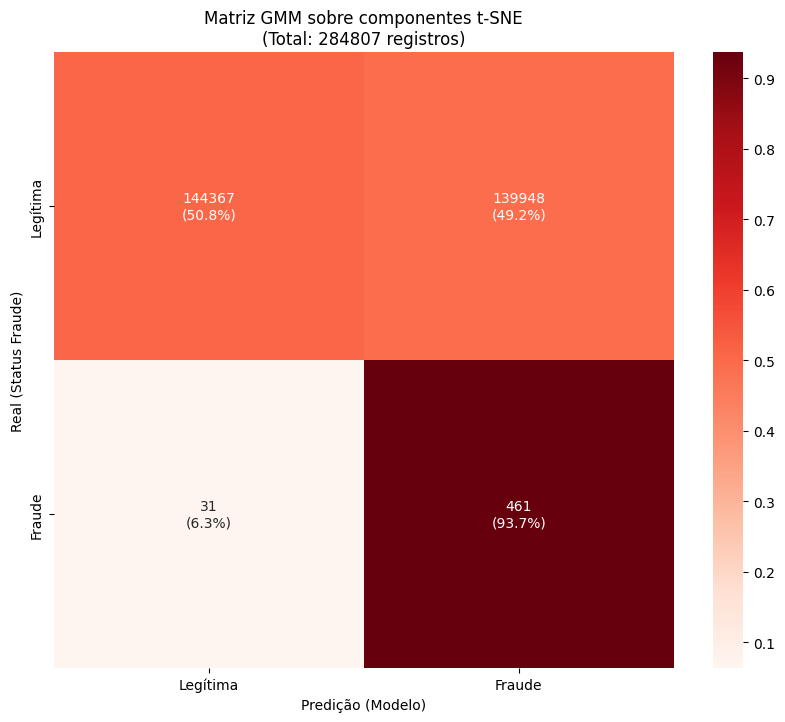


AUC-PR FINAL: 0.0059
              precision    recall  f1-score   support

    Legítima       1.00      0.51      0.67    284315
      Fraude       0.00      0.94      0.01       492

    accuracy                           0.51    284807
   macro avg       0.50      0.72      0.34    284807
weighted avg       1.00      0.51      0.67    284807



In [159]:
#PREPARAÇÃO DOS DADOS DO t-SNE 
# Usando o DataFrame que você já criou (df_plot)
X_tsne_cols = df_plot[['TSNE_1', 'TSNE_2']]
y_real = df_plot['status_fraude']

#MODELAGEM GMM
# Treinando nos dados transformados pelo t-SNE
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_tsne_cols)

#Identificando o cluster de fraude automaticamente
clusters = gmm.predict(X_tsne_cols)
ct = pd.crosstab(clusters, y_real)
cluster_fraude = ct[1].idxmax()

#Pegando as probabilidades
probabilidades = gmm.predict_proba(X_tsne_cols)[:, cluster_fraude]
y_pred = (probabilidades > 0.50).astype(int)

#MÉTRICAS E MATRIZ 
cm = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

#Criando labels com Bruto + Porcentagem
labels = [f"{int(val)}\n({pct:.1%})" for val, pct in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(2, 2)

#VISUALIZAÇÃO 
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm, 
    annot=labels, 
    fmt="", 
    cmap='Reds', 
    xticklabels=['Legítima', 'Fraude'], 
    yticklabels=['Legítima', 'Fraude']
)

plt.title(f'Matriz GMM sobre componentes t-SNE\n(Total: {len(df_plot)} registros)')
plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')
plt.show()

# Relatório de Mercado
precision_vals, recall_vals, _ = precision_recall_curve(y_real, probabilidades)
print("\n" + "="*40)
print(f"AUC-PR FINAL: {auc(recall_vals, precision_vals):.4f}")
print("="*40)
print(classification_report(y_real, y_pred, target_names=['Legítima', 'Fraude']))

# 3st 

### ORIGINAL



RANK ESCOLHIDO: 3
FEATURE: V10 | V11


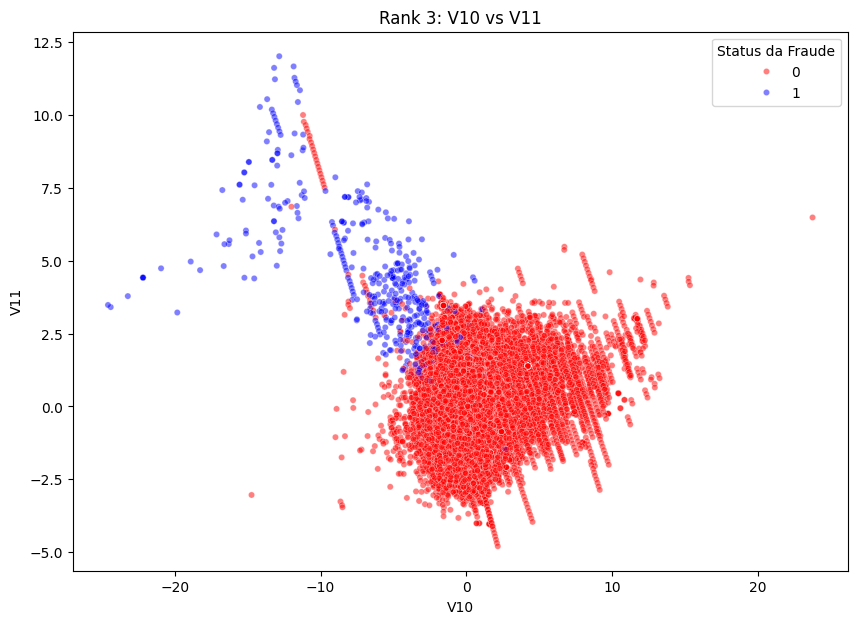

In [160]:
posicao_rank = 3
# 1 = melhor dupla
# 2 = segunda melhor
# ...

# PEGAR FEATURE ESCOLHIDA
feature_escolhida = features_list[posicao_rank - 1]

x, y = feature_escolhida.split('|')

x = x.strip()
y = y.strip()

print('\n=========================')
print(f'RANK ESCOLHIDO: {posicao_rank}')
print(f'FEATURE: {feature_escolhida}')
print('=========================')


# GRÁFICO 2D
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x=x,
    y=y,
    hue='status_fraude',
    palette={
        0: 'red',
        1: 'blue'
    },
    alpha=0.5,
    s=20
)

plt.title(f'Rank {posicao_rank}: {x} vs {y}')

plt.xlabel(x)
plt.ylabel(y)

plt.legend(title='Status da Fraude')

plt.show()


#### GMM NA ORIGINAL 

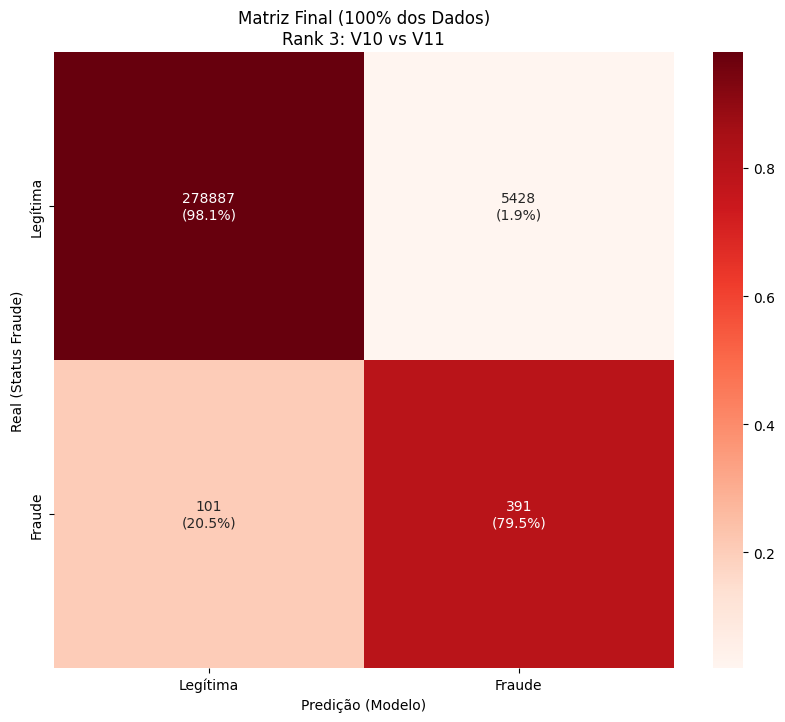

Tempo de execução: 5.1583s
Total de registros analisados: 284807

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    284315
           1       0.07      0.79      0.12       492

    accuracy                           0.98    284807
   macro avg       0.53      0.89      0.56    284807
weighted avg       1.00      0.98      0.99    284807

AUC-PR: 0.2498


In [161]:


#DEFINIÇÃO DAS VARIÁVEIS DO RANKING
feature_escolhida = features_list[posicao_rank - 1]
x_col, y_col = [f.strip() for f in feature_escolhida.split('|')]

X_bruto = df[[x_col, y_col]]
y_real = df['status_fraude']

#ESCALONAMENTO E TREINO (GMM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bruto)

inicio = time.perf_counter()
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
fim = time.perf_counter()

#IDENTIFICAÇÃO DO CLUSTER DE FRAUDE
clusters = gmm.predict(X_scaled)
ct = pd.crosstab(clusters, y_real)
cluster_fraude = ct[1].idxmax() # Qual cluster tem mais fraudes (1)

#PREDIÇÃO E PROBABILIDADE
probabilidades = gmm.predict_proba(X_scaled)[:, cluster_fraude]
y_pred = (probabilidades > 0.50).astype(int)

#MATRIZ DE CONFUSÃO (BRUTO + PORCENTAGEM)
cm = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

#Formatação dos Labels para mostrar valor real e %
labels = [f"{int(val)}\n({pct:.1%})" for val, pct in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(2, 2)

#VISUALIZAÇÃO
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=labels, fmt="", cmap='Reds',
            xticklabels=['Legítima', 'Fraude'], 
            yticklabels=['Legítima', 'Fraude'])

plt.title(f'Matriz Final (100% dos Dados)\nRank {posicao_rank}: {x_col} vs {y_col}')
plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')
plt.show()

#MÉTRICAS DE MERCADO NO TERMINAL
print(f"Tempo de execução: {fim - inicio:.4f}s")
print(f"Total de registros analisados: {len(df)}")
print("\nRelatório de Classificação:")
print(classification_report(y_real, y_pred))

precision_vals, recall_vals, _ = precision_recall_curve(y_real, probabilidades)
print(f"AUC-PR: {auc(recall_vals, precision_vals):.4f}")

### T-SNE

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=7, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 99.53 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 29.47 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.17 seconds
===> Running optimization with exaggeration=12.00, lr=23733.92 for 250 iterations...
Iteration   50, KL divergence 6.2590, 50 iterations in 22.6877 sec
Iteration  100, KL divergence 5.7943, 50 iterations in 22.3429 sec
Iteration  150, KL divergence 5.3639, 50 iterations in 22.8701 sec
Iteration  200, KL divergence 5.0945, 50 iterations in 22.3014 sec
Iteration  250, KL divergence 4.9009, 50 iterations in 22.1046 sec
   --> Time elapsed: 112.31 seconds
===> Running optimization with exag

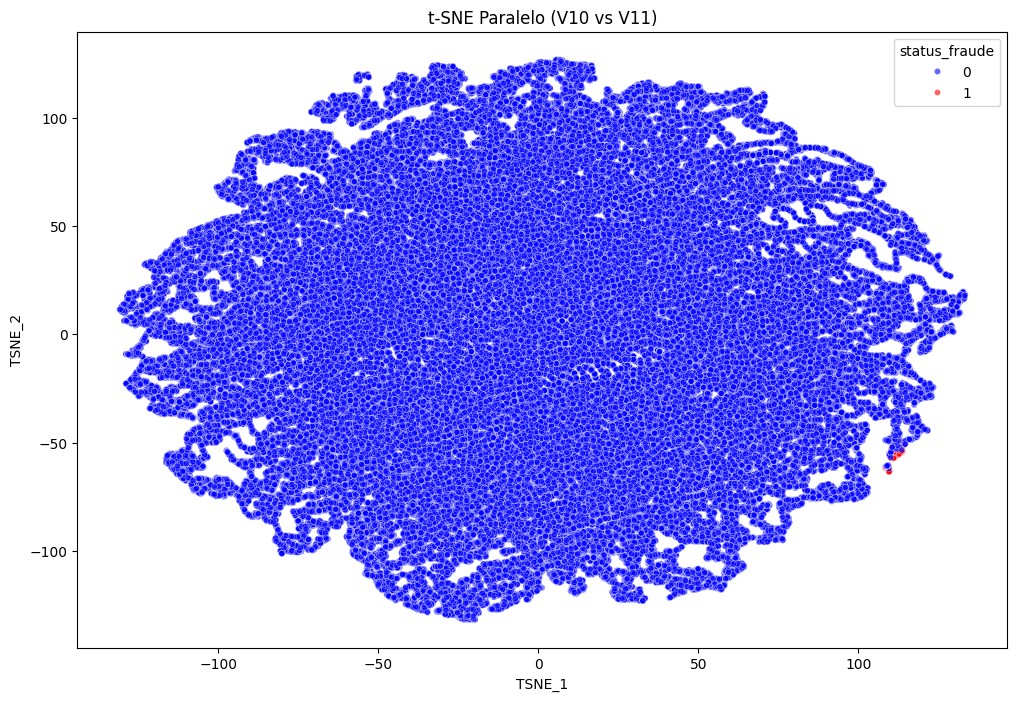

In [162]:
feature_escolhida = features_list[posicao_rank - 1]

x, y = feature_escolhida.split('|')

x = x.strip()
y = y.strip()

# FRAUDES E NÃO FRAUDES
df_fraude = df[df['status_fraude'] == 1]

df_nao_fraude = df[df['status_fraude'] == 0]


df_nao_fraude_sample = df_nao_fraude.sample(
    frac=1.0,
    random_state=42
)

#Juntando
df_tsne = pd.concat(
    [df_fraude, df_nao_fraude_sample],
    axis=0
)
 
#FEATURES

X = df_tsne[[x, y]]

#Padronização
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# t-SNE PARALELO
tsne = TSNE(
    n_components=2,
    perplexity=30,
    initialization='pca',
    n_jobs=7,
    random_state=42,
    verbose=True
)

X_tsne = tsne.fit(X_scaled)

# DATAFRAME FINAL
df_plot = pd.DataFrame()

df_plot['TSNE_1'] = X_tsne[:, 0]
df_plot['TSNE_2'] = X_tsne[:, 1]

df_plot['status_fraude'] = df_tsne['status_fraude'].values

#PLOT 
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_plot,
    x='TSNE_1',
    y='TSNE_2',
    hue='status_fraude',
    palette={
        0: 'blue',
        1: 'red'
    },
    alpha=0.6,
    s=20
)

plt.title(
    f't-SNE Paralelo ({x} vs {y})'
)

plt.show()

#### GMM NA T-SNE

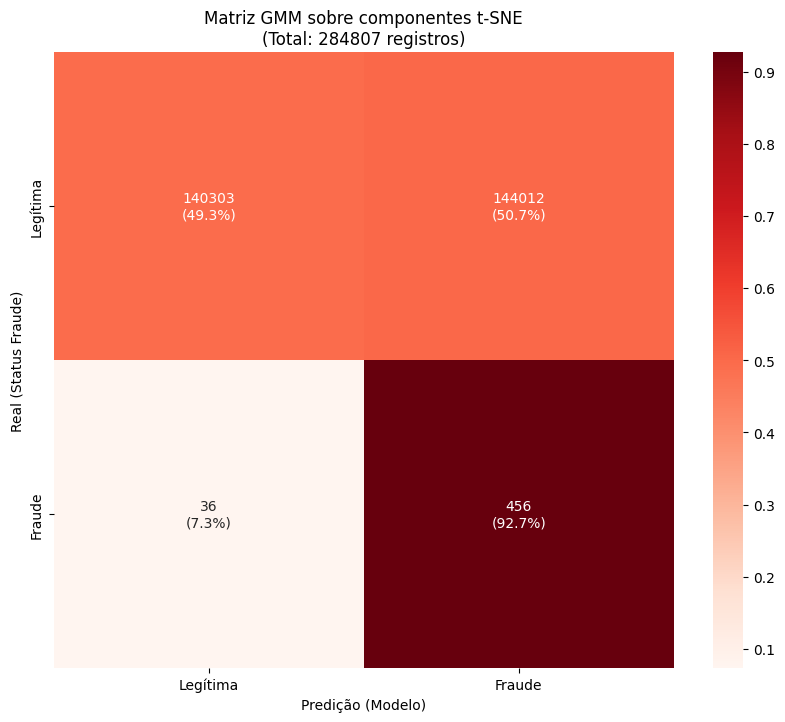


AUC-PR FINAL: 0.0046
              precision    recall  f1-score   support

    Legítima       1.00      0.49      0.66    284315
      Fraude       0.00      0.93      0.01       492

    accuracy                           0.49    284807
   macro avg       0.50      0.71      0.33    284807
weighted avg       1.00      0.49      0.66    284807



In [163]:
#PREPARAÇÃO DOS DADOS DO t-SNE 
# Usando o DataFrame que você já criou (df_plot)
X_tsne_cols = df_plot[['TSNE_1', 'TSNE_2']]
y_real = df_plot['status_fraude']

#MODELAGEM GMM
# Treinando nos dados transformados pelo t-SNE
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_tsne_cols)

#Identificando o cluster de fraude automaticamente
clusters = gmm.predict(X_tsne_cols)
ct = pd.crosstab(clusters, y_real)
cluster_fraude = ct[1].idxmax()

#Pegando as probabilidades
probabilidades = gmm.predict_proba(X_tsne_cols)[:, cluster_fraude]
y_pred = (probabilidades > 0.50).astype(int)

#MÉTRICAS E MATRIZ 
cm = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

#Criando labels com Bruto + Porcentagem
labels = [f"{int(val)}\n({pct:.1%})" for val, pct in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(2, 2)

#VISUALIZAÇÃO 
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm, 
    annot=labels, 
    fmt="", 
    cmap='Reds', 
    xticklabels=['Legítima', 'Fraude'], 
    yticklabels=['Legítima', 'Fraude']
)

plt.title(f'Matriz GMM sobre componentes t-SNE\n(Total: {len(df_plot)} registros)')
plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')
plt.show()

# Relatório de Mercado
precision_vals, recall_vals, _ = precision_recall_curve(y_real, probabilidades)
print("\n" + "="*40)
print(f"AUC-PR FINAL: {auc(recall_vals, precision_vals):.4f}")
print("="*40)
print(classification_report(y_real, y_pred, target_names=['Legítima', 'Fraude']))

# 4st 

### ORIGINAL



RANK ESCOLHIDO: 4
FEATURE: V14 | V17


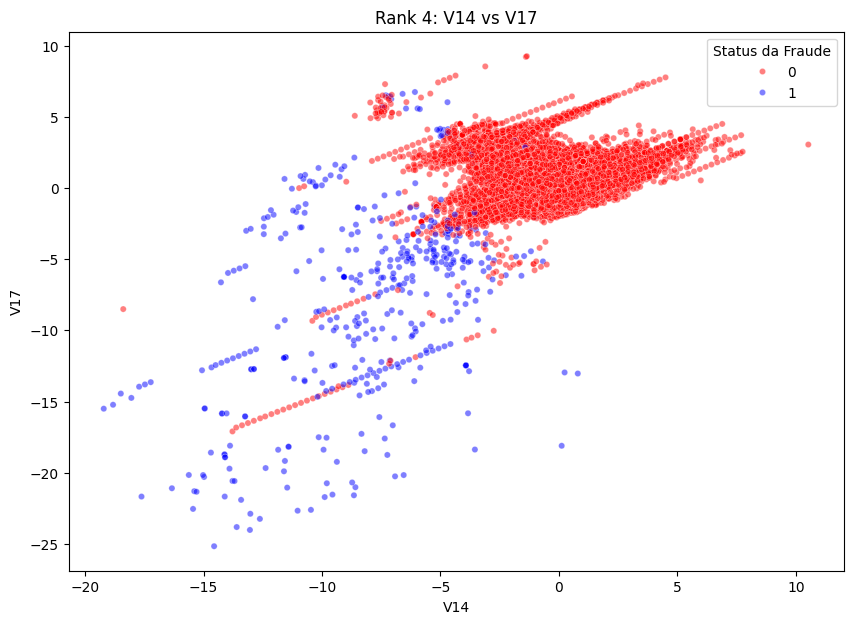

In [164]:
posicao_rank = 4
# 1 = melhor dupla
# 2 = segunda melhor
# ...

# PEGAR FEATURE ESCOLHIDA
feature_escolhida = features_list[posicao_rank - 1]

x, y = feature_escolhida.split('|')

x = x.strip()
y = y.strip()

print('\n=========================')
print(f'RANK ESCOLHIDO: {posicao_rank}')
print(f'FEATURE: {feature_escolhida}')
print('=========================')


# GRÁFICO 2D
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x=x,
    y=y,
    hue='status_fraude',
    palette={
        0: 'red',
        1: 'blue'
    },
    alpha=0.5,
    s=20
)

plt.title(f'Rank {posicao_rank}: {x} vs {y}')

plt.xlabel(x)
plt.ylabel(y)

plt.legend(title='Status da Fraude')

plt.show()


#### GMM NA ORIGINAL 

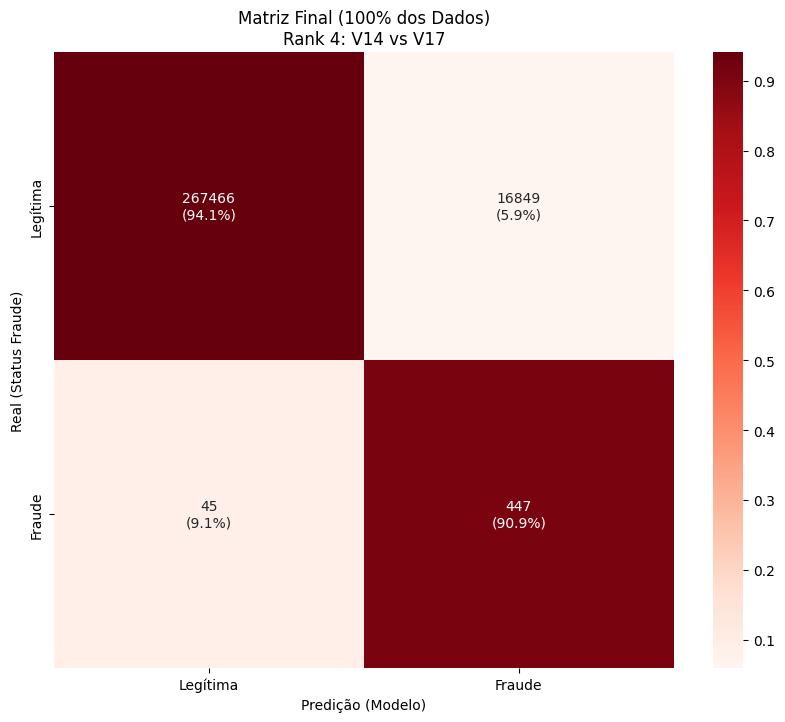

Tempo de execução: 3.2105s
Total de registros analisados: 284807

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    284315
           1       0.03      0.91      0.05       492

    accuracy                           0.94    284807
   macro avg       0.51      0.92      0.51    284807
weighted avg       1.00      0.94      0.97    284807

AUC-PR: 0.6236


In [165]:
#DEFINIÇÃO DAS VARIÁVEIS DO RANKING
feature_escolhida = features_list[posicao_rank - 1]
x_col, y_col = [f.strip() for f in feature_escolhida.split('|')]

X_bruto = df[[x_col, y_col]]
y_real = df['status_fraude']

#ESCALONAMENTO E TREINO (GMM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bruto)

inicio = time.perf_counter()
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
fim = time.perf_counter()

#IDENTIFICAÇÃO DO CLUSTER DE FRAUDE
clusters = gmm.predict(X_scaled)
ct = pd.crosstab(clusters, y_real)
cluster_fraude = ct[1].idxmax() # Qual cluster tem mais fraudes (1)

#PREDIÇÃO E PROBABILIDADE
probabilidades = gmm.predict_proba(X_scaled)[:, cluster_fraude]
y_pred = (probabilidades > 0.50).astype(int)

#MATRIZ DE CONFUSÃO (BRUTO + PORCENTAGEM)
cm = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

#Formatação dos Labels para mostrar valor real e %
labels = [f"{int(val)}\n({pct:.1%})" for val, pct in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(2, 2)

#VISUALIZAÇÃO
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=labels, fmt="", cmap='Reds',
            xticklabels=['Legítima', 'Fraude'], 
            yticklabels=['Legítima', 'Fraude'])

plt.title(f'Matriz Final (100% dos Dados)\nRank {posicao_rank}: {x_col} vs {y_col}')
plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')
plt.show()

#MÉTRICAS DE MERCADO NO TERMINAL
print(f"Tempo de execução: {fim - inicio:.4f}s")
print(f"Total de registros analisados: {len(df)}")
print("\nRelatório de Classificação:")
print(classification_report(y_real, y_pred))

precision_vals, recall_vals, _ = precision_recall_curve(y_real, probabilidades)
print(f"AUC-PR: {auc(recall_vals, precision_vals):.4f}")

### T-SNE

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=7, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 107.09 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 31.74 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.16 seconds
===> Running optimization with exaggeration=12.00, lr=23733.92 for 250 iterations...
Iteration   50, KL divergence 6.2698, 50 iterations in 24.6178 sec
Iteration  100, KL divergence 5.8000, 50 iterations in 24.3359 sec
Iteration  150, KL divergence 5.3683, 50 iterations in 22.5595 sec
Iteration  200, KL divergence 5.0994, 50 iterations in 22.1060 sec
Iteration  250, KL divergence 4.9070, 50 iterations in 22.2910 sec
   --> Time elapsed: 115.92 seconds
===> Running optimization with exa

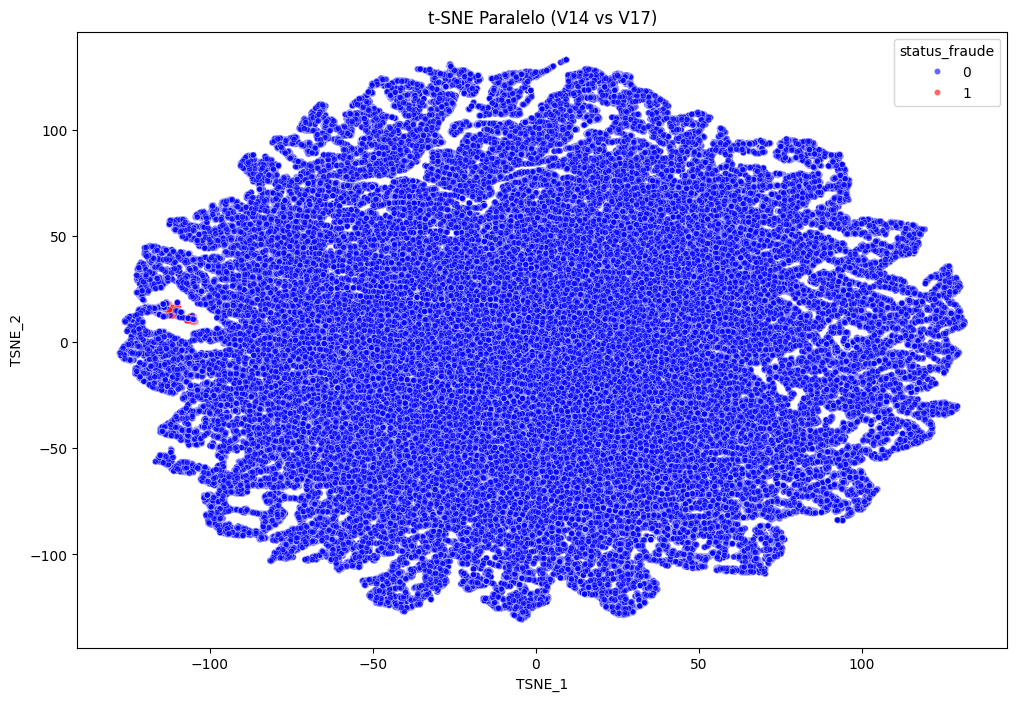

In [166]:
feature_escolhida = features_list[posicao_rank - 1]

x, y = feature_escolhida.split('|')

x = x.strip()
y = y.strip()

# FRAUDES E NÃO FRAUDES
df_fraude = df[df['status_fraude'] == 1]

df_nao_fraude = df[df['status_fraude'] == 0]


df_nao_fraude_sample = df_nao_fraude.sample(
    frac=1.0,
    random_state=42
)

#Juntando
df_tsne = pd.concat(
    [df_fraude, df_nao_fraude_sample],
    axis=0
)
 
#FEATURES

X = df_tsne[[x, y]]

#Padronização
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# t-SNE PARALELO
tsne = TSNE(
    n_components=2,
    perplexity=30,
    initialization='pca',
    n_jobs=7,
    random_state=42,
    verbose=True
)

X_tsne = tsne.fit(X_scaled)

# DATAFRAME FINAL
df_plot = pd.DataFrame()

df_plot['TSNE_1'] = X_tsne[:, 0]
df_plot['TSNE_2'] = X_tsne[:, 1]

df_plot['status_fraude'] = df_tsne['status_fraude'].values

#PLOT 
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_plot,
    x='TSNE_1',
    y='TSNE_2',
    hue='status_fraude',
    palette={
        0: 'blue',
        1: 'red'
    },
    alpha=0.6,
    s=20
)

plt.title(
    f't-SNE Paralelo ({x} vs {y})'
)

plt.show()

#### GMM NA T-SNE

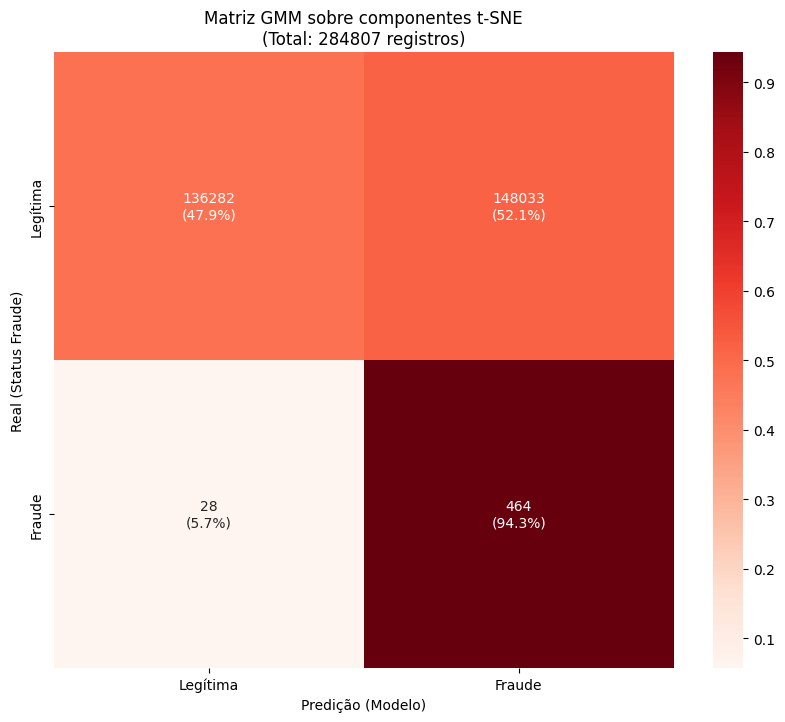


AUC-PR FINAL: 0.0290
              precision    recall  f1-score   support

    Legítima       1.00      0.48      0.65    284315
      Fraude       0.00      0.94      0.01       492

    accuracy                           0.48    284807
   macro avg       0.50      0.71      0.33    284807
weighted avg       1.00      0.48      0.65    284807



In [167]:
#PREPARAÇÃO DOS DADOS DO t-SNE 
# Usando o DataFrame que você já criou (df_plot)
X_tsne_cols = df_plot[['TSNE_1', 'TSNE_2']]
y_real = df_plot['status_fraude']

#MODELAGEM GMM
# Treinando nos dados transformados pelo t-SNE
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_tsne_cols)

#Identificando o cluster de fraude automaticamente
clusters = gmm.predict(X_tsne_cols)
ct = pd.crosstab(clusters, y_real)
cluster_fraude = ct[1].idxmax()

#Pegando as probabilidades
probabilidades = gmm.predict_proba(X_tsne_cols)[:, cluster_fraude]
y_pred = (probabilidades > 0.50).astype(int)

#MÉTRICAS E MATRIZ 
cm = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

#Criando labels com Bruto + Porcentagem
labels = [f"{int(val)}\n({pct:.1%})" for val, pct in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(2, 2)

#VISUALIZAÇÃO 
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm, 
    annot=labels, 
    fmt="", 
    cmap='Reds', 
    xticklabels=['Legítima', 'Fraude'], 
    yticklabels=['Legítima', 'Fraude']
)

plt.title(f'Matriz GMM sobre componentes t-SNE\n(Total: {len(df_plot)} registros)')
plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')
plt.show()

# Relatório de Mercado
precision_vals, recall_vals, _ = precision_recall_curve(y_real, probabilidades)
print("\n" + "="*40)
print(f"AUC-PR FINAL: {auc(recall_vals, precision_vals):.4f}")
print("="*40)
print(classification_report(y_real, y_pred, target_names=['Legítima', 'Fraude']))

# 5st 

### ORIGINAL



RANK ESCOLHIDO: 5
FEATURE: V11 | V17


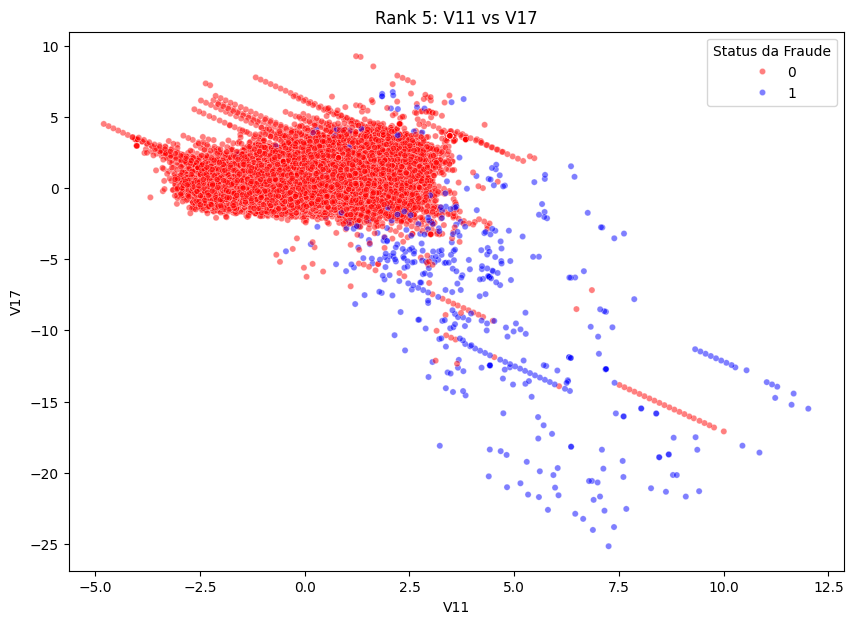

In [168]:
posicao_rank = 5
# 1 = melhor dupla
# 2 = segunda melhor
# ...

# PEGAR FEATURE ESCOLHIDA
feature_escolhida = features_list[posicao_rank - 1]

x, y = feature_escolhida.split('|')

x = x.strip()
y = y.strip()

print('\n=========================')
print(f'RANK ESCOLHIDO: {posicao_rank}')
print(f'FEATURE: {feature_escolhida}')
print('=========================')


# GRÁFICO 2D
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x=x,
    y=y,
    hue='status_fraude',
    palette={
        0: 'red',
        1: 'blue'
    },
    alpha=0.5,
    s=20
)

plt.title(f'Rank {posicao_rank}: {x} vs {y}')

plt.xlabel(x)
plt.ylabel(y)

plt.legend(title='Status da Fraude')

plt.show()


#### GMM NA ORIGINAL 

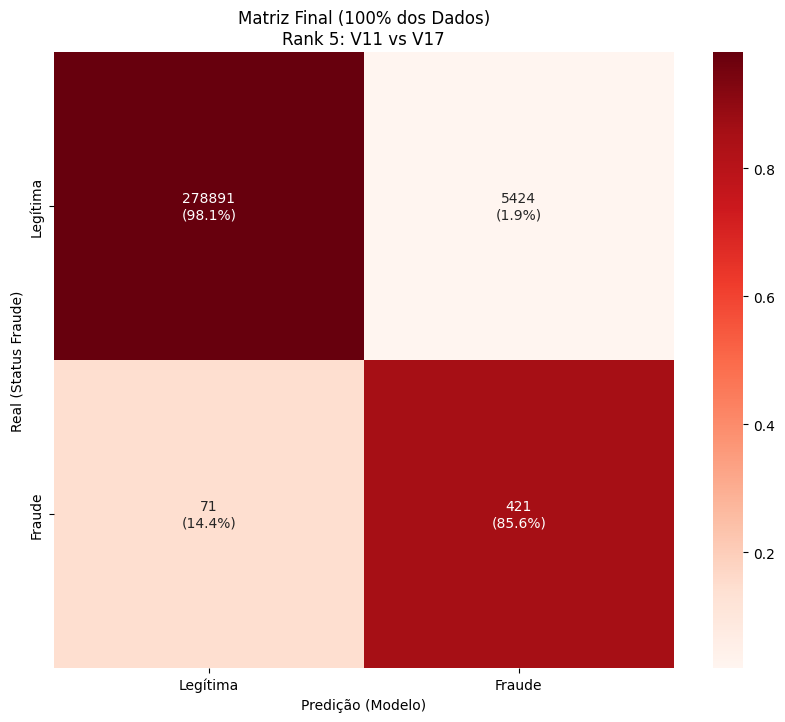

Tempo de execução: 5.4361s
Total de registros analisados: 284807

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    284315
           1       0.07      0.86      0.13       492

    accuracy                           0.98    284807
   macro avg       0.54      0.92      0.56    284807
weighted avg       1.00      0.98      0.99    284807

AUC-PR: 0.5791


In [169]:


#DEFINIÇÃO DAS VARIÁVEIS DO RANKING
feature_escolhida = features_list[posicao_rank - 1]
x_col, y_col = [f.strip() for f in feature_escolhida.split('|')]

X_bruto = df[[x_col, y_col]]
y_real = df['status_fraude']

#ESCALONAMENTO E TREINO (GMM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bruto)

inicio = time.perf_counter()
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
fim = time.perf_counter()

#IDENTIFICAÇÃO DO CLUSTER DE FRAUDE
clusters = gmm.predict(X_scaled)
ct = pd.crosstab(clusters, y_real)
cluster_fraude = ct[1].idxmax() # Qual cluster tem mais fraudes (1)

#PREDIÇÃO E PROBABILIDADE
probabilidades = gmm.predict_proba(X_scaled)[:, cluster_fraude]
y_pred = (probabilidades > 0.50).astype(int)

#MATRIZ DE CONFUSÃO (BRUTO + PORCENTAGEM)
cm = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

#Formatação dos Labels para mostrar valor real e %
labels = [f"{int(val)}\n({pct:.1%})" for val, pct in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(2, 2)

#VISUALIZAÇÃO
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=labels, fmt="", cmap='Reds',
            xticklabels=['Legítima', 'Fraude'], 
            yticklabels=['Legítima', 'Fraude'])

plt.title(f'Matriz Final (100% dos Dados)\nRank {posicao_rank}: {x_col} vs {y_col}')
plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')
plt.show()

#MÉTRICAS DE MERCADO NO TERMINAL
print(f"Tempo de execução: {fim - inicio:.4f}s")
print(f"Total de registros analisados: {len(df)}")
print("\nRelatório de Classificação:")
print(classification_report(y_real, y_pred))

precision_vals, recall_vals, _ = precision_recall_curve(y_real, probabilidades)
print(f"AUC-PR: {auc(recall_vals, precision_vals):.4f}")

### T-SNE

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=7, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 101.37 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 31.18 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.14 seconds
===> Running optimization with exaggeration=12.00, lr=23733.92 for 250 iterations...
Iteration   50, KL divergence 6.2534, 50 iterations in 21.8497 sec
Iteration  100, KL divergence 5.7869, 50 iterations in 22.3798 sec
Iteration  150, KL divergence 5.3547, 50 iterations in 22.3817 sec
Iteration  200, KL divergence 5.0841, 50 iterations in 22.1194 sec
Iteration  250, KL divergence 4.8895, 50 iterations in 22.3311 sec
   --> Time elapsed: 111.07 seconds
===> Running optimization with exa

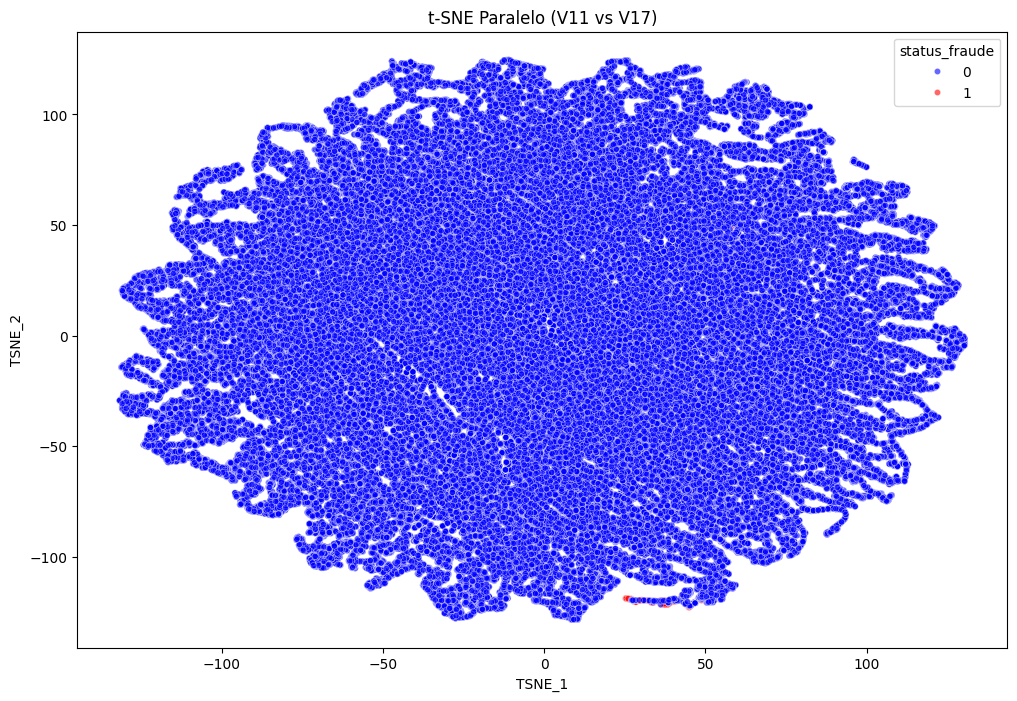

In [170]:
feature_escolhida = features_list[posicao_rank - 1]

x, y = feature_escolhida.split('|')

x = x.strip()
y = y.strip()

# FRAUDES E NÃO FRAUDES
df_fraude = df[df['status_fraude'] == 1]

df_nao_fraude = df[df['status_fraude'] == 0]


df_nao_fraude_sample = df_nao_fraude.sample(
    frac=1.0,
    random_state=42
)

#Juntando
df_tsne = pd.concat(
    [df_fraude, df_nao_fraude_sample],
    axis=0
)
 
#FEATURES

X = df_tsne[[x, y]]

#Padronização
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# t-SNE PARALELO
tsne = TSNE(
    n_components=2,
    perplexity=30,
    initialization='pca',
    n_jobs=7,
    random_state=42,
    verbose=True
)

X_tsne = tsne.fit(X_scaled)

# DATAFRAME FINAL
df_plot = pd.DataFrame()

df_plot['TSNE_1'] = X_tsne[:, 0]
df_plot['TSNE_2'] = X_tsne[:, 1]

df_plot['status_fraude'] = df_tsne['status_fraude'].values

#PLOT 
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_plot,
    x='TSNE_1',
    y='TSNE_2',
    hue='status_fraude',
    palette={
        0: 'blue',
        1: 'red'
    },
    alpha=0.6,
    s=20
)

plt.title(
    f't-SNE Paralelo ({x} vs {y})'
)

plt.show()

#### GMM NA T-SNE

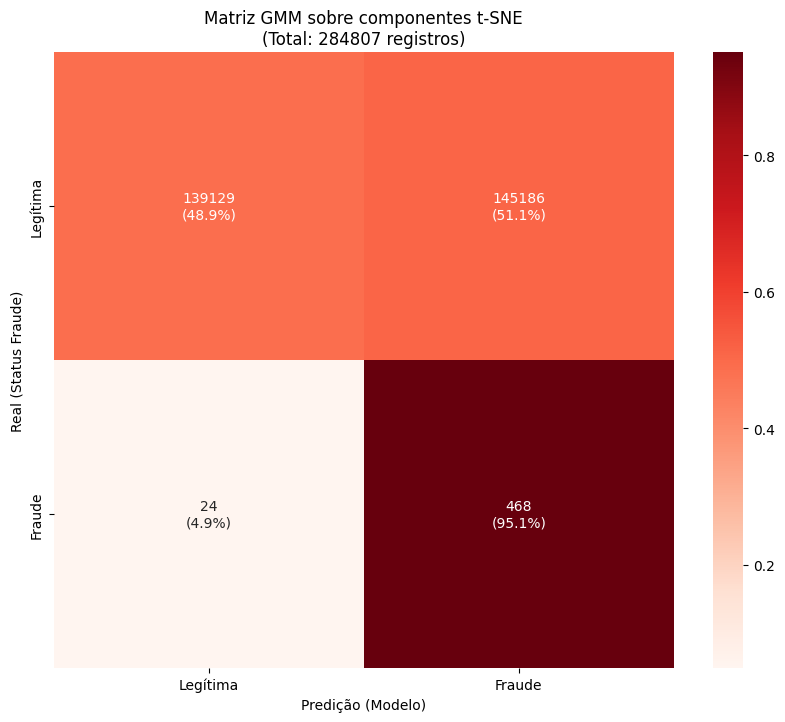


AUC-PR FINAL: 0.0040
              precision    recall  f1-score   support

    Legítima       1.00      0.49      0.66    284315
      Fraude       0.00      0.95      0.01       492

    accuracy                           0.49    284807
   macro avg       0.50      0.72      0.33    284807
weighted avg       1.00      0.49      0.66    284807



In [171]:
#PREPARAÇÃO DOS DADOS DO t-SNE 
# Usando o DataFrame que você já criou (df_plot)
X_tsne_cols = df_plot[['TSNE_1', 'TSNE_2']]
y_real = df_plot['status_fraude']

#MODELAGEM GMM
# Treinando nos dados transformados pelo t-SNE
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_tsne_cols)

#Identificando o cluster de fraude automaticamente
clusters = gmm.predict(X_tsne_cols)
ct = pd.crosstab(clusters, y_real)
cluster_fraude = ct[1].idxmax()

#Pegando as probabilidades
probabilidades = gmm.predict_proba(X_tsne_cols)[:, cluster_fraude]
y_pred = (probabilidades > 0.50).astype(int)

#MÉTRICAS E MATRIZ 
cm = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

#Criando labels com Bruto + Porcentagem
labels = [f"{int(val)}\n({pct:.1%})" for val, pct in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(2, 2)

#VISUALIZAÇÃO 
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm, 
    annot=labels, 
    fmt="", 
    cmap='Reds', 
    xticklabels=['Legítima', 'Fraude'], 
    yticklabels=['Legítima', 'Fraude']
)

plt.title(f'Matriz GMM sobre componentes t-SNE\n(Total: {len(df_plot)} registros)')
plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')
plt.show()

# Relatório de Mercado
precision_vals, recall_vals, _ = precision_recall_curve(y_real, probabilidades)
print("\n" + "="*40)
print(f"AUC-PR FINAL: {auc(recall_vals, precision_vals):.4f}")
print("="*40)
print(classification_report(y_real, y_pred, target_names=['Legítima', 'Fraude']))

##### FIM DA MARCACAO DE TEMPO


In [172]:
fim = time.perf_counter()
print(f"O programa levou {fim - inicio:.4f} segundos para rodar, obrigado.")

O programa levou 768.4623 segundos para rodar, obrigado.
